**CHAPTER 4**
**TEXT PRE-PROCESSING PADA DATA KOMENTAR TIKTOK HASIL WEB SCRAPING**



Nama: Tabrizzi Aqlia
NIM: 25031554008

Pada Exercise 4 ini, saya menerapkan materi Text Pre-processing pada data komentar TikTok yang saya ambil menggunakan program web scraping dari tugas sebelumnya. Jadi, saya tidak melakukan scraping dari awal menggunakan metode baru, tetapi menggunakan kembali program scraping yang sudah dibuat sebelumnya untuk memperoleh data komentar TikTok.

Setelah data berhasil diperoleh, saya menggunakan kolom text sebagai data utama karena kolom tersebut berisi isi komentar dari pengguna TikTok. Kemudian, data tersebut saya proses menggunakan tahapan text preprocessing sesuai materi Chapter 4.

Tahap pertama adalah cleaning, yaitu membersihkan teks dari elemen-elemen yang tidak diperlukan seperti hashtag, URL, tanda baca, dan karakter yang tidak relevan. Setelah itu dilakukan lowercase atau case folding, yaitu mengubah seluruh huruf menjadi huruf kecil agar penulisan kata menjadi seragam.

Selanjutnya dilakukan stopword removal, yaitu menghilangkan kata-kata umum yang dianggap kurang memberikan informasi dalam analisis teks. Setelah itu dilakukan stemming menggunakan library Sastrawi untuk mengubah kata berimbuhan Bahasa Indonesia menjadi bentuk dasarnya.

Hasil dari seluruh proses preprocessing tersebut kemudian saya simpan pada kolom prepro. Saya juga tetap mempertahankan kolom text_original supaya dapat membandingkan kondisi komentar sebelum dan sesudah preprocessing.

Dengan demikian, data yang awalnya berupa komentar TikTok yang masih mengandung berbagai elemen yang tidak diperlukan menjadi teks yang lebih bersih dan siap digunakan untuk proses analisis teks selanjutnya.

In [1]:
!pip install -q apify-client pandas openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.2/160.2 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 8.2 MB/s eta 0:00:00


In [3]:
!pip install apify-client

In [4]:
from apify_client import ApifyClient

In [5]:
client = ApifyClient("apify_api_DIivCDNfY4ClmcH5Wczo8Zyi9Ey6Ze19xM2S")

In [6]:
run_input = {
    "commentsPerPost": 120,
    "excludePinnedPosts": False,
    "maxRepliesPerComment": 5,
    "postURLs": [
        "https://vt.tiktok.com/ZSqcuwEQm/"
    ],
    "resultsPerPage": 100
}

In [7]:
run = client.actor(
    "clockworks/tiktok-comments-scraper"
).call(run_input=run_input)

[apify.tiktok-comments-scraper runId:DfkVNXuy5VsFEHIUc] -> Status: RUNNING, Message: 
[apify.tiktok-comments-scraper runId:DfkVNXuy5VsFEHIUc] -> 2026-09-29T11:50:30.182Z ACTOR: Pulling container image of build KuIVFI6IU118eMMQg from registry.
[apify.tiktok-comments-scraper runId:DfkVNXuy5VsFEHIUc] -> 2026-09-29T11:50:30.185Z ACTOR: Creating container.
[apify.tiktok-comments-scraper runId:DfkVNXuy5VsFEHIUc] -> 2026-09-29T11:50:30.268Z ACTOR: Starting container.
[apify.tiktok-comments-scraper runId:DfkVNXuy5VsFEHIUc] -> 2026-09-29T11:50:30.270Z ACTOR: Running under "LIMITED_PERMISSIONS".
[apify.tiktok-comments-scraper runId:DfkVNXuy5VsFEHIUc] -> 2026-09-29T11:50:30.362Z Running on architecture: x86_64
[apify.tiktok-comments-scraper runId:DfkVNXuy5VsFEHIUc] -> 2026-09-29T11:50:30.364Z Will run command: xvfb-run -a -s "-ac -screen 0 1920x1080x24+32 -nolisten tcp" /bin/bash -o pipefail -c bash -c "    java         --enable-native-access=ALL-UNNAMED         -cp classes-test:classes-main:lib/

In [9]:
dataset_id = run.default_dataset_id

items = list(
    client.dataset(dataset_id).iterate_items()
)

print("Jumlah data:", len(items))

Jumlah data: 120


In [10]:
for i, item in enumerate(items, 1):
    print(f"{i}. {item.get('text', '')}")

1. kirain diera Prabowo bakal lebih baik, ternyata...🥺 🥺
2. di Kalimantan masih menderita, Wowo malah healing ke rusia.
3. sawit.....oh.......sawit.
4. y allah trunkan hjn untuk soudara2ku di kalimntn🥺
5. hanya di Indonesia punya hutan beribu2 hektar tapi tidak punya satupun pesawat pemadam kebakaran
6. yg salahin presiden org yg sakit hati 😹
7. Enak nya hidup di Indonesia, mencaci maki pemerintah, menghina presiden, rakyat nya masih hidup bahagia,, klo di Luar negeri mungkin kalian udah Meninggal / penjara..
8. Masih belum ada statement permintaan maaf pada negara tetangga dari pemerintah kita. its so fucking crazy, gila ni rezim gila.
9. zolim amat si prabowo ini semua demi nanam sawit
10. kamu pikir ini nggak sengaja?
km hidup di masa pejabat2 yg jhat.
dan tahun depan kalian pilih lg orang semacam itu lg. dan ngeluh lg..
i
11. ada daerah yg udah mulai turun hujan.. smoga juga Kalimantan scptnya turun hujan
12. Aku nangis mikirin hewan di dalam hutan😭😭😭
13. alhmdulillah gasyy , di Ka

DATA SCRAPING BERHASIL
Jumlah data: 120

Dataset berhasil dibuat.
Jumlah baris : 120
Jumlah kolom : 7


,No,Username,Waktu,Komentar,Like,Jumlah Reply,Panjang Komentar
0,1,b3w_real,02-09-2026 19:56:49,"kirain diera Prabowo bakal lebih baik, ternyat...",800,58.0,53
1,2,jack.ngibul,02-09-2026 19:55:33,"di Kalimantan masih menderita, Wowo malah heal...",2527,63.0,59
2,3,johanson06,02-09-2026 19:56:24,sawit.....oh.......sawit.,34,4.0,25
3,4,nikengama,02-09-2026 21:05:51,y allah trunkan hjn untuk soudara2ku di kalimntn🥺,18,1.0,49
4,5,anindira1231,03-09-2026 06:34:05,hanya di Indonesia punya hutan beribu2 hektar ...,969,25.0,96
...,...,...,...,...,...,...,...
115,116,may.syarah88,13-09-2026 15:10:47,bukan hanya Prabowo aja yg menjabat sebagai pr...,0,NaN,194
116,117,tabasco.gfs,07-09-2026 03:06:57,pemerintah udah banyak melakukan tindakan pada...,1,NaN,308
117,118,delova0921,13-09-2026 23:30:18,satu bln dana mbg Udah besi bli pesawat gobl.....,0,NaN,50
118,119,notattract1ve,02-09-2026 21:24:21,kenyang kenyangin makan berita hoks,9,NaN,35



CEK DATA KOSONG
No                   0
Username             0
Waktu                0
Komentar             0
Like                 0
Jumlah Reply        73
Panjang Komentar     0
dtype: int64

STATISTIK DATA
Jumlah komentar          : 120
Total Like               : 6631
Rata-rata Like           : 55.26
Total Reply              : 446.0
Rata-rata Reply          : 9.49
Rata-rata panjang teks   : 86.72

TOP 10 KOMENTAR BERDASARKAN LIKE


,Username,Waktu,Komentar,Like,Jumlah Reply
1,jack.ngibul,02-09-2026 19:55:33,"di Kalimantan masih menderita, Wowo malah heal...",2527,63.0
4,anindira1231,03-09-2026 06:34:05,hanya di Indonesia punya hutan beribu2 hektar ...,969,25.0
0,b3w_real,02-09-2026 19:56:49,"kirain diera Prabowo bakal lebih baik, ternyat...",800,58.0
11,ira17168,02-09-2026 20:11:22,Aku nangis mikirin hewan di dalam hutan😭😭😭,588,16.0
55,wodi32500,02-09-2026 23:26:04,98 ada krisis aja dia kabur ke Jordan 😂,242,NaN
10,monde2557,02-09-2026 20:12:18,ada daerah yg udah mulai turun hujan.. smoga j...,207,6.0
30,myyy249,03-09-2026 08:15:51,"mana nih influencer yg pd milih si gemoy, mana...",164,18.0
14,user2294792220020,02-09-2026 21:57:47,negara gagal dikelola penguasanya..anti kritik...,133,5.0
99,zyan.alfathir,02-09-2026 20:53:09,kenapa pak Prabowo yg salah?dasar dongo,102,NaN
13,syaqilashop05,02-09-2026 20:36:28,kangen komen tiktok kalo ada musibah penuh doa...,74,5.0



20 KATA PALING SERING MUNCUL


,Kata,Frekuensi
0,kebakaran,17
1,pemerintah,16
2,kami,16
3,kalimantan,13
4,pesawat,13
5,rakyat,13
6,negara,13
7,gk,13
8,sawit,11
9,presiden,10


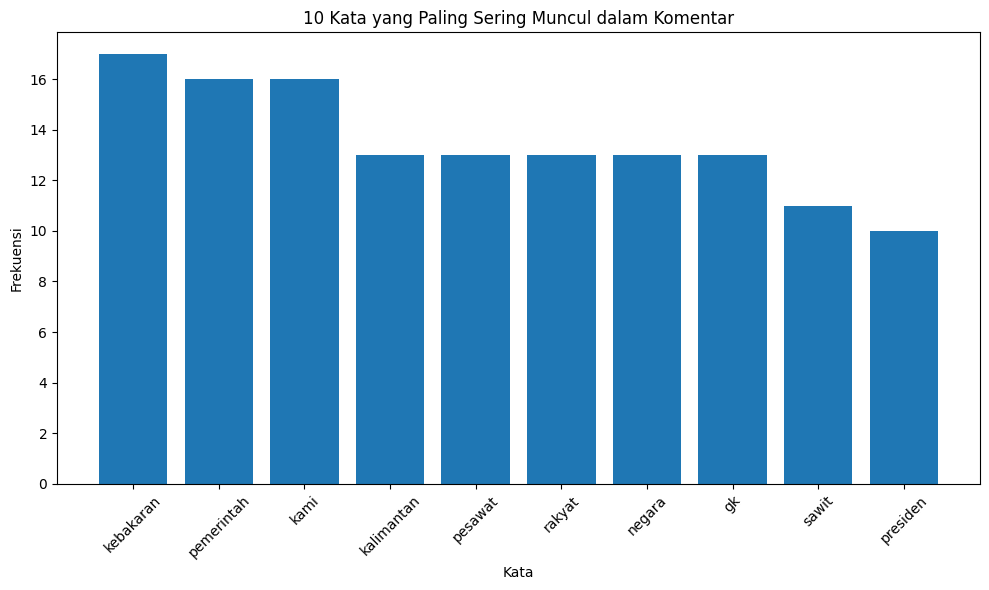

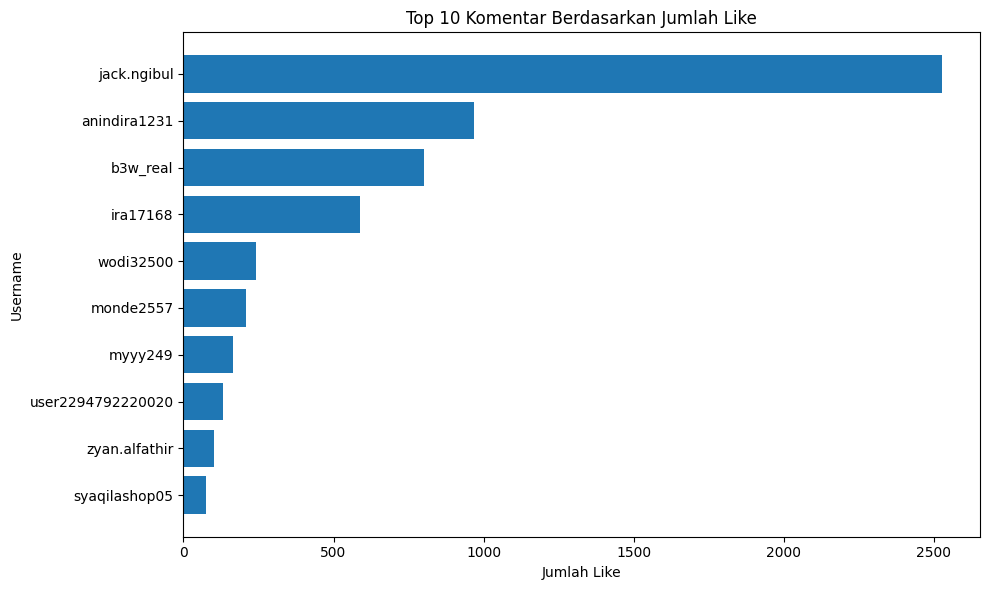

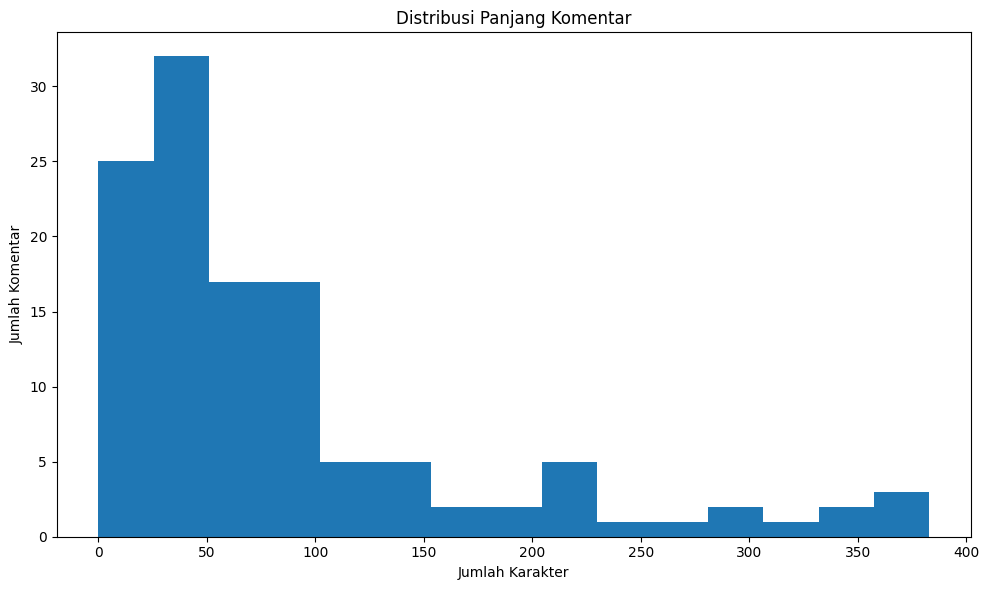


KOMENTAR DENGAN LIKE TERTINGGI
Username : jack.ngibul
Waktu    : 02-09-2026 19:55:33
Like     : 2527
Komentar : di Kalimantan masih menderita, Wowo malah healing ke rusia.

KOMENTAR TERPANJANG
Username : bryantviolinnn
Waktu    : 04-09-2026 13:56:20
Panjang  : 383
Komentar : Tingkat bencana ini skalanya nasional, bahkan dampaknya menyebar sampai ke negara lain. Oke, bukan presiden yg bakar, tp tugas dia menetapkan skala prioritas spy negara bs kerahkan bantuan dgn benar. Dimana empati dan solusinya padahal sdh separah ini? Kalian yg belain, mau dibayar atau ngga, emg nya kalian masih bakal berpikiran sama kl kejadian ini menimpa tempat tinggal kalian?

EXPORT BERHASIL
File: analisis_komentar_tiktok.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from collections import Counter
from datetime import datetime
from zoneinfo import ZoneInfo

# ==========================================
# 1. MENGAMBIL DATA DARI APIFY
# ==========================================

dataset_id = run.default_dataset_id

items = list(
    client.dataset(dataset_id).iterate_items()
)

print("=" * 60)
print("DATA SCRAPING BERHASIL")
print("=" * 60)
print("Jumlah data:", len(items))


# ==========================================
# 2. MEMBUAT DATASET
# ==========================================

data = []

for i, item in enumerate(items, 1):

    username = item.get("uniqueId", "")
    komentar = item.get("text", "")
    waktu = item.get("createTimeISO", "")

    like = item.get("diggCount", 0)
    reply = item.get("replyCommentTotal", 0)

    # Konversi waktu UTC ke WIB
    if waktu:
        try:
            dt = datetime.fromisoformat(
                waktu.replace("Z", "+00:00")
            )
            dt = dt.astimezone(
                ZoneInfo("Asia/Jakarta")
            )
            waktu_wib = dt.strftime(
                "%d-%m-%Y %H:%M:%S"
            )
        except:
            waktu_wib = waktu
    else:
        waktu_wib = ""

    # Panjang komentar
    panjang = len(komentar)

    data.append({
        "No": i,
        "Username": username,
        "Waktu": waktu_wib,
        "Komentar": komentar,
        "Like": like,
        "Jumlah Reply": reply,
        "Panjang Komentar": panjang
    })


# ==========================================
# 3. DATAFRAME
# ==========================================

df = pd.DataFrame(data)

print("\nDataset berhasil dibuat.")
print("Jumlah baris :", len(df))
print("Jumlah kolom :", len(df.columns))

display(df)


# ==========================================
# 4. CEK DATA KOSONG
# ==========================================

print("\n" + "=" * 60)
print("CEK DATA KOSONG")
print("=" * 60)

print(df.isnull().sum())


# ==========================================
# 5. STATISTIK DATA
# ==========================================

print("\n" + "=" * 60)
print("STATISTIK DATA")
print("=" * 60)

print("Jumlah komentar          :", len(df))
print("Total Like               :", df["Like"].sum())
print("Rata-rata Like           :", round(df["Like"].mean(), 2))
print("Total Reply              :", df["Jumlah Reply"].sum())
print("Rata-rata Reply          :", round(df["Jumlah Reply"].mean(), 2))
print("Rata-rata panjang teks   :", round(df["Panjang Komentar"].mean(), 2))


# ==========================================
# 6. TOP 10 KOMENTAR BERDASARKAN LIKE
# ==========================================

print("\n" + "=" * 60)
print("TOP 10 KOMENTAR BERDASARKAN LIKE")
print("=" * 60)

top_10 = df.sort_values(
    by="Like",
    ascending=False
).head(10)

display(
    top_10[
        [
            "Username",
            "Waktu",
            "Komentar",
            "Like",
            "Jumlah Reply"
        ]
    ]
)


# ==========================================
# 7. PREPROCESSING TEKS
# ==========================================

stopwords = {
    "yang", "dan", "atau", "ini", "itu",
    "ada", "untuk", "dari", "saya", "aku",
    "kamu", "dia", "nya", "banget", "bgt",
    "aja", "sih", "di", "ke", "dan",
    "ga", "gak", "nggak", "tidak",
    "ya", "yg", "dengan", "jadi",
    "udah", "sudah", "kok", "lah",
    "nih", "tuh", "pun"
}


def preprocessing(teks):

    teks = str(teks).lower()

    # Hapus URL
    teks = re.sub(
        r"http\S+|www\S+",
        "",
        teks
    )

    # Hapus username/mention
    teks = re.sub(
        r"@\w+",
        "",
        teks
    )

    # Hapus hashtag tetapi tetap mempertahankan katanya
    teks = re.sub(
        r"#",
        "",
        teks
    )

    # Hanya mengambil huruf
    teks = re.sub(
        r"[^a-zA-ZÀ-ÿ\s]",
        " ",
        teks
    )

    # Pecah menjadi kata
    kata = teks.split()

    # Hapus stopwords
    kata = [
        k for k in kata
        if k not in stopwords
    ]

    return kata


df["Kata Bersih"] = df["Komentar"].apply(
    preprocessing
)


# ==========================================
# 8. MENCARI 20 KATA PALING SERING MUNCUL
# ==========================================

semua_kata = []

for daftar_kata in df["Kata Bersih"]:
    semua_kata.extend(daftar_kata)

frekuensi = Counter(semua_kata)

top_kata = pd.DataFrame(
    frekuensi.most_common(20),
    columns=[
        "Kata",
        "Frekuensi"
    ]
)

print("\n" + "=" * 60)
print("20 KATA PALING SERING MUNCUL")
print("=" * 60)

display(top_kata)


# ==========================================
# 9. VISUALISASI TOP 10 KATA
# ==========================================

plt.figure(figsize=(10, 6))

plt.bar(
    top_kata["Kata"].head(10),
    top_kata["Frekuensi"].head(10)
)

plt.title(
    "10 Kata yang Paling Sering Muncul dalam Komentar"
)

plt.xlabel("Kata")
plt.ylabel("Frekuensi")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


# ==========================================
# 10. VISUALISASI TOP 10 KOMENTAR BERDASARKAN LIKE
# ==========================================

plt.figure(figsize=(10, 6))

plt.barh(
    top_10["Username"].astype(str),
    top_10["Like"]
)

plt.title(
    "Top 10 Komentar Berdasarkan Jumlah Like"
)

plt.xlabel("Jumlah Like")
plt.ylabel("Username")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()


# ==========================================
# 11. DISTRIBUSI PANJANG KOMENTAR
# ==========================================

plt.figure(figsize=(10, 6))

plt.hist(
    df["Panjang Komentar"],
    bins=15
)

plt.title(
    "Distribusi Panjang Komentar"
)

plt.xlabel("Jumlah Karakter")
plt.ylabel("Jumlah Komentar")

plt.tight_layout()

plt.show()


# ==========================================
# 12. KOMENTAR DENGAN LIKE TERTINGGI
# ==========================================

komentar_tertinggi = df.loc[
    df["Like"].idxmax()
]

print("\n" + "=" * 60)
print("KOMENTAR DENGAN LIKE TERTINGGI")
print("=" * 60)

print("Username :", komentar_tertinggi["Username"])
print("Waktu    :", komentar_tertinggi["Waktu"])
print("Like     :", komentar_tertinggi["Like"])
print("Komentar :", komentar_tertinggi["Komentar"])


# ==========================================
# 13. KOMENTAR TERPANJANG
# ==========================================

komentar_terpanjang = df.loc[
    df["Panjang Komentar"].idxmax()
]

print("\n" + "=" * 60)
print("KOMENTAR TERPANJANG")
print("=" * 60)

print("Username :", komentar_terpanjang["Username"])
print("Waktu    :", komentar_terpanjang["Waktu"])
print("Panjang  :", komentar_terpanjang["Panjang Komentar"])
print("Komentar :", komentar_terpanjang["Komentar"])


# ==========================================
# 14. EXPORT DATASET KE EXCEL
# ==========================================

df_export = df.drop(
    columns=["Kata Bersih"]
)

nama_file = "analisis_komentar_tiktok.xlsx"

df_export.to_excel(
    nama_file,
    index=False
)

print("\n" + "=" * 60)
print("EXPORT BERHASIL")
print("=" * 60)

print("File:", nama_file)


# ==========================================
# 15. DOWNLOAD EXCEL
# ==========================================

from google.colab import files

files.download(
    nama_file
)

In [12]:
!pip install -q apify-client pandas openpyxl

In [13]:
client = ApifyClient("apify_api_DIivCDNfY4ClmcH5Wczo8Zyi9Ey6Ze19xM2S")

Mengambil 10 Sampel dari 120 data komentar TikTok

In [14]:
df = pd.DataFrame(items)

print("Jumlah data:", len(df))
print("Kolom:")
print(df.columns.tolist())

display(df.head(10))

Jumlah data: 120
Kolom:
['videoWebUrl', 'submittedVideoUrl', 'input', 'cid', 'createTime', 'createTimeISO', 'text', 'diggCount', 'likedByAuthor', 'pinnedByAuthor', 'repliesToId', 'replyCommentTotal', 'uid', 'uniqueId', 'avatarThumbnail', 'mentions', 'detailedMentions']


,videoWebUrl,submittedVideoUrl,input,cid,createTime,createTimeISO,text,diggCount,likedByAuthor,pinnedByAuthor,repliesToId,replyCommentTotal,uid,uniqueId,avatarThumbnail,mentions,detailedMentions
0,https://www.tiktok.com/@officialinews/video/76...,https://vt.tiktok.com/ZSqcuwEQm/,https://vt.tiktok.com/ZSqcuwEQm/,7680921069234078484,1788353809,2026-09-02T12:56:49.000Z,"kirain diera Prabowo bakal lebih baik, ternyat...",800,False,False,None,58.0,6976662298702955525,b3w_real,https://p19-common-sign.tiktokcdn-us.com/tos-a...,[],[]
1,https://www.tiktok.com/@officialinews/video/76...,https://vt.tiktok.com/ZSqcuwEQm/,https://vt.tiktok.com/ZSqcuwEQm/,7680920753575133960,1788353733,2026-09-02T12:55:33.000Z,"di Kalimantan masih menderita, Wowo malah heal...",2527,False,False,None,63.0,7614882899138380818,jack.ngibul,https://p16-common-sign.tiktokcdn-us.com/tos-a...,[],[]
2,https://www.tiktok.com/@officialinews/video/76...,https://vt.tiktok.com/ZSqcuwEQm/,https://vt.tiktok.com/ZSqcuwEQm/,7680920987390837522,1788353784,2026-09-02T12:56:24.000Z,sawit.....oh.......sawit.,34,False,False,None,4.0,7211470240495387650,johanson06,https://p19-common-sign.tiktokcdn-us.com/tos-m...,[],[]
3,https://www.tiktok.com/@officialinews/video/76...,https://vt.tiktok.com/ZSqcuwEQm/,https://vt.tiktok.com/ZSqcuwEQm/,7680938824315503381,1788357951,2026-09-02T14:05:51.000Z,y allah trunkan hjn untuk soudara2ku di kalimntn🥺,18,False,False,None,1.0,7015366685474128923,nikengama,https://p16-common-sign.tiktokcdn-us.com/tos-a...,[],[]
4,https://www.tiktok.com/@officialinews/video/76...,https://vt.tiktok.com/ZSqcuwEQm/,https://vt.tiktok.com/ZSqcuwEQm/,7681085216903316244,1788392045,2026-09-02T23:34:05.000Z,hanya di Indonesia punya hutan beribu2 hektar ...,969,False,False,None,25.0,7184758227484804098,anindira1231,https://p19-common-sign.tiktokcdn-us.com/tos-m...,[],[]
5,https://www.tiktok.com/@officialinews/video/76...,https://vt.tiktok.com/ZSqcuwEQm/,https://vt.tiktok.com/ZSqcuwEQm/,7680969292611011349,1788365035,2026-09-02T16:03:55.000Z,yg salahin presiden org yg sakit hati 😹,11,False,False,None,49.0,7572203857888576533,mayorteddymaytedl,https://p16-common-sign.tiktokcdn-us.com/tos-a...,[],[]
6,https://www.tiktok.com/@officialinews/video/76...,https://vt.tiktok.com/ZSqcuwEQm/,https://vt.tiktok.com/ZSqcuwEQm/,7681198327387882260,1788418368,2026-09-03T06:52:48.000Z,"Enak nya hidup di Indonesia, mencaci maki peme...",7,False,False,None,28.0,6944527203129508865,gemini_doraemon,https://p19-common-sign.tiktokcdn-us.com/tos-m...,[],[]
7,https://www.tiktok.com/@officialinews/video/76...,https://vt.tiktok.com/ZSqcuwEQm/,https://vt.tiktok.com/ZSqcuwEQm/,7681133011778142994,1788403165,2026-09-03T02:39:25.000Z,Masih belum ada statement permintaan maaf pada...,37,False,False,None,12.0,7566516293437424647,moochie592,https://p19-common-sign.tiktokcdn-us.com/tos-a...,[],[]
8,https://www.tiktok.com/@officialinews/video/76...,https://vt.tiktok.com/ZSqcuwEQm/,https://vt.tiktok.com/ZSqcuwEQm/,7681093960082162453,1788394481,2026-09-03T00:14:41.000Z,zolim amat si prabowo ini semua demi nanam sawit,16,False,False,None,15.0,7532729934189134855,azmeng,https://p16-common-sign.tiktokcdn-us.com/tos-a...,[],[]
9,https://www.tiktok.com/@officialinews/video/76...,https://vt.tiktok.com/ZSqcuwEQm/,https://vt.tiktok.com/ZSqcuwEQm/,7680928311429661460,1788355500,2026-09-02T13:25:00.000Z,kamu pikir ini nggak sengaja?\nkm hidup di mas...,24,False,False,None,11.0,7519990496945718290,rafa_aljava,https://p16-common-sign.tiktokcdn-us.com/tos-a...,[],[]


In [15]:
df = pd.DataFrame(items)

print("Jumlah data:", len(df))
print("Jumlah kolom:", len(df.columns))
print("Nama kolom:")
print(df.columns.tolist())

display(df.head(10))

Jumlah data: 120
Jumlah kolom: 17
Nama kolom:
['videoWebUrl', 'submittedVideoUrl', 'input', 'cid', 'createTime', 'createTimeISO', 'text', 'diggCount', 'likedByAuthor', 'pinnedByAuthor', 'repliesToId', 'replyCommentTotal', 'uid', 'uniqueId', 'avatarThumbnail', 'mentions', 'detailedMentions']


,videoWebUrl,submittedVideoUrl,input,cid,createTime,createTimeISO,text,diggCount,likedByAuthor,pinnedByAuthor,repliesToId,replyCommentTotal,uid,uniqueId,avatarThumbnail,mentions,detailedMentions
0,https://www.tiktok.com/@officialinews/video/76...,https://vt.tiktok.com/ZSqcuwEQm/,https://vt.tiktok.com/ZSqcuwEQm/,7680921069234078484,1788353809,2026-09-02T12:56:49.000Z,"kirain diera Prabowo bakal lebih baik, ternyat...",800,False,False,None,58.0,6976662298702955525,b3w_real,https://p19-common-sign.tiktokcdn-us.com/tos-a...,[],[]
1,https://www.tiktok.com/@officialinews/video/76...,https://vt.tiktok.com/ZSqcuwEQm/,https://vt.tiktok.com/ZSqcuwEQm/,7680920753575133960,1788353733,2026-09-02T12:55:33.000Z,"di Kalimantan masih menderita, Wowo malah heal...",2527,False,False,None,63.0,7614882899138380818,jack.ngibul,https://p16-common-sign.tiktokcdn-us.com/tos-a...,[],[]
2,https://www.tiktok.com/@officialinews/video/76...,https://vt.tiktok.com/ZSqcuwEQm/,https://vt.tiktok.com/ZSqcuwEQm/,7680920987390837522,1788353784,2026-09-02T12:56:24.000Z,sawit.....oh.......sawit.,34,False,False,None,4.0,7211470240495387650,johanson06,https://p19-common-sign.tiktokcdn-us.com/tos-m...,[],[]
3,https://www.tiktok.com/@officialinews/video/76...,https://vt.tiktok.com/ZSqcuwEQm/,https://vt.tiktok.com/ZSqcuwEQm/,7680938824315503381,1788357951,2026-09-02T14:05:51.000Z,y allah trunkan hjn untuk soudara2ku di kalimntn🥺,18,False,False,None,1.0,7015366685474128923,nikengama,https://p16-common-sign.tiktokcdn-us.com/tos-a...,[],[]
4,https://www.tiktok.com/@officialinews/video/76...,https://vt.tiktok.com/ZSqcuwEQm/,https://vt.tiktok.com/ZSqcuwEQm/,7681085216903316244,1788392045,2026-09-02T23:34:05.000Z,hanya di Indonesia punya hutan beribu2 hektar ...,969,False,False,None,25.0,7184758227484804098,anindira1231,https://p19-common-sign.tiktokcdn-us.com/tos-m...,[],[]
5,https://www.tiktok.com/@officialinews/video/76...,https://vt.tiktok.com/ZSqcuwEQm/,https://vt.tiktok.com/ZSqcuwEQm/,7680969292611011349,1788365035,2026-09-02T16:03:55.000Z,yg salahin presiden org yg sakit hati 😹,11,False,False,None,49.0,7572203857888576533,mayorteddymaytedl,https://p16-common-sign.tiktokcdn-us.com/tos-a...,[],[]
6,https://www.tiktok.com/@officialinews/video/76...,https://vt.tiktok.com/ZSqcuwEQm/,https://vt.tiktok.com/ZSqcuwEQm/,7681198327387882260,1788418368,2026-09-03T06:52:48.000Z,"Enak nya hidup di Indonesia, mencaci maki peme...",7,False,False,None,28.0,6944527203129508865,gemini_doraemon,https://p19-common-sign.tiktokcdn-us.com/tos-m...,[],[]
7,https://www.tiktok.com/@officialinews/video/76...,https://vt.tiktok.com/ZSqcuwEQm/,https://vt.tiktok.com/ZSqcuwEQm/,7681133011778142994,1788403165,2026-09-03T02:39:25.000Z,Masih belum ada statement permintaan maaf pada...,37,False,False,None,12.0,7566516293437424647,moochie592,https://p19-common-sign.tiktokcdn-us.com/tos-a...,[],[]
8,https://www.tiktok.com/@officialinews/video/76...,https://vt.tiktok.com/ZSqcuwEQm/,https://vt.tiktok.com/ZSqcuwEQm/,7681093960082162453,1788394481,2026-09-03T00:14:41.000Z,zolim amat si prabowo ini semua demi nanam sawit,16,False,False,None,15.0,7532729934189134855,azmeng,https://p16-common-sign.tiktokcdn-us.com/tos-a...,[],[]
9,https://www.tiktok.com/@officialinews/video/76...,https://vt.tiktok.com/ZSqcuwEQm/,https://vt.tiktok.com/ZSqcuwEQm/,7680928311429661460,1788355500,2026-09-02T13:25:00.000Z,kamu pikir ini nggak sengaja?\nkm hidup di mas...,24,False,False,None,11.0,7519990496945718290,rafa_aljava,https://p16-common-sign.tiktokcdn-us.com/tos-a...,[],[]


In [16]:
df[['uniqueId', 'text', 'createTimeISO', 'diggCount']].head(10)

,uniqueId,text,createTimeISO,diggCount
0,b3w_real,"kirain diera Prabowo bakal lebih baik, ternyat...",2026-09-02T12:56:49.000Z,800
1,jack.ngibul,"di Kalimantan masih menderita, Wowo malah heal...",2026-09-02T12:55:33.000Z,2527
2,johanson06,sawit.....oh.......sawit.,2026-09-02T12:56:24.000Z,34
3,nikengama,y allah trunkan hjn untuk soudara2ku di kalimntn🥺,2026-09-02T14:05:51.000Z,18
4,anindira1231,hanya di Indonesia punya hutan beribu2 hektar ...,2026-09-02T23:34:05.000Z,969
5,mayorteddymaytedl,yg salahin presiden org yg sakit hati 😹,2026-09-02T16:03:55.000Z,11
6,gemini_doraemon,"Enak nya hidup di Indonesia, mencaci maki peme...",2026-09-03T06:52:48.000Z,7
7,moochie592,Masih belum ada statement permintaan maaf pada...,2026-09-03T02:39:25.000Z,37
8,azmeng,zolim amat si prabowo ini semua demi nanam sawit,2026-09-03T00:14:41.000Z,16
9,rafa_aljava,kamu pikir ini nggak sengaja?\nkm hidup di mas...,2026-09-02T13:25:00.000Z,24


Ubah items menjadi DataFrame

In [22]:
data = pd.DataFrame(items)

print(type(data))
print(data.shape)

<class 'pandas.core.frame.DataFrame'>
(120, 17)


In [23]:
print(data.columns.tolist())

['videoWebUrl', 'submittedVideoUrl', 'input', 'cid', 'createTime', 'createTimeISO', 'text', 'diggCount', 'likedByAuthor', 'pinnedByAuthor', 'repliesToId', 'replyCommentTotal', 'uid', 'uniqueId', 'avatarThumbnail', 'mentions', 'detailedMentions']


In [24]:
data['text_original'] = data['text']
data[['text_original']].head(10)

,text_original
0,"kirain diera Prabowo bakal lebih baik, ternyat..."
1,"di Kalimantan masih menderita, Wowo malah heal..."
2,sawit.....oh.......sawit.
3,y allah trunkan hjn untuk soudara2ku di kalimntn🥺
4,hanya di Indonesia punya hutan beribu2 hektar ...
5,yg salahin presiden org yg sakit hati 😹
6,"Enak nya hidup di Indonesia, mencaci maki peme..."
7,Masih belum ada statement permintaan maaf pada...
8,zolim amat si prabowo ini semua demi nanam sawit
9,kamu pikir ini nggak sengaja?\nkm hidup di mas...


**Ubah semua huruf menjadi lowercase.**

In [25]:
data['text_clean'] = data['text'].astype(str).str.lower()

data[['text_original', 'text_clean']].head(10)

,text_original,text_clean
0,"kirain diera Prabowo bakal lebih baik, ternyat...","kirain diera prabowo bakal lebih baik, ternyat..."
1,"di Kalimantan masih menderita, Wowo malah heal...","di kalimantan masih menderita, wowo malah heal..."
2,sawit.....oh.......sawit.,sawit.....oh.......sawit.
3,y allah trunkan hjn untuk soudara2ku di kalimntn🥺,y allah trunkan hjn untuk soudara2ku di kalimntn🥺
4,hanya di Indonesia punya hutan beribu2 hektar ...,hanya di indonesia punya hutan beribu2 hektar ...
5,yg salahin presiden org yg sakit hati 😹,yg salahin presiden org yg sakit hati 😹
6,"Enak nya hidup di Indonesia, mencaci maki peme...","enak nya hidup di indonesia, mencaci maki peme..."
7,Masih belum ada statement permintaan maaf pada...,masih belum ada statement permintaan maaf pada...
8,zolim amat si prabowo ini semua demi nanam sawit,zolim amat si prabowo ini semua demi nanam sawit
9,kamu pikir ini nggak sengaja?\nkm hidup di mas...,kamu pikir ini nggak sengaja?\nkm hidup di mas...


**Remove URL**

In [26]:
import re

data['text_clean'] = data['text_clean'].apply(
    lambda x: re.sub(r'http\S+|www\S+|https\S+', '', x)
)

data[['text_original', 'text_clean']].head(10)

,text_original,text_clean
0,"kirain diera Prabowo bakal lebih baik, ternyat...","kirain diera prabowo bakal lebih baik, ternyat..."
1,"di Kalimantan masih menderita, Wowo malah heal...","di kalimantan masih menderita, wowo malah heal..."
2,sawit.....oh.......sawit.,sawit.....oh.......sawit.
3,y allah trunkan hjn untuk soudara2ku di kalimntn🥺,y allah trunkan hjn untuk soudara2ku di kalimntn🥺
4,hanya di Indonesia punya hutan beribu2 hektar ...,hanya di indonesia punya hutan beribu2 hektar ...
5,yg salahin presiden org yg sakit hati 😹,yg salahin presiden org yg sakit hati 😹
6,"Enak nya hidup di Indonesia, mencaci maki peme...","enak nya hidup di indonesia, mencaci maki peme..."
7,Masih belum ada statement permintaan maaf pada...,masih belum ada statement permintaan maaf pada...
8,zolim amat si prabowo ini semua demi nanam sawit,zolim amat si prabowo ini semua demi nanam sawit
9,kamu pikir ini nggak sengaja?\nkm hidup di mas...,kamu pikir ini nggak sengaja?\nkm hidup di mas...


**Remove Mention & Hashtag**

In [27]:
data['text_clean'] = data['text_clean'].apply(
    lambda x: re.sub(r'@\w+|#\w+', '', x)
)

data[['text_original', 'text_clean']].head(10)

,text_original,text_clean
0,"kirain diera Prabowo bakal lebih baik, ternyat...","kirain diera prabowo bakal lebih baik, ternyat..."
1,"di Kalimantan masih menderita, Wowo malah heal...","di kalimantan masih menderita, wowo malah heal..."
2,sawit.....oh.......sawit.,sawit.....oh.......sawit.
3,y allah trunkan hjn untuk soudara2ku di kalimntn🥺,y allah trunkan hjn untuk soudara2ku di kalimntn🥺
4,hanya di Indonesia punya hutan beribu2 hektar ...,hanya di indonesia punya hutan beribu2 hektar ...
5,yg salahin presiden org yg sakit hati 😹,yg salahin presiden org yg sakit hati 😹
6,"Enak nya hidup di Indonesia, mencaci maki peme...","enak nya hidup di indonesia, mencaci maki peme..."
7,Masih belum ada statement permintaan maaf pada...,masih belum ada statement permintaan maaf pada...
8,zolim amat si prabowo ini semua demi nanam sawit,zolim amat si prabowo ini semua demi nanam sawit
9,kamu pikir ini nggak sengaja?\nkm hidup di mas...,kamu pikir ini nggak sengaja?\nkm hidup di mas...


**Hapus tanda baca**

In [28]:
data['text_clean'] = data['text_clean'].apply(
    lambda x: re.sub(r'[^\w\s]', '', x)
)

data[['text_original', 'text_clean']].head(10)

,text_original,text_clean
0,"kirain diera Prabowo bakal lebih baik, ternyat...",kirain diera prabowo bakal lebih baik ternyata
1,"di Kalimantan masih menderita, Wowo malah heal...",di kalimantan masih menderita wowo malah heali...
2,sawit.....oh.......sawit.,sawitohsawit
3,y allah trunkan hjn untuk soudara2ku di kalimntn🥺,y allah trunkan hjn untuk soudara2ku di kalimntn
4,hanya di Indonesia punya hutan beribu2 hektar ...,hanya di indonesia punya hutan beribu2 hektar ...
5,yg salahin presiden org yg sakit hati 😹,yg salahin presiden org yg sakit hati
6,"Enak nya hidup di Indonesia, mencaci maki peme...",enak nya hidup di indonesia mencaci maki pemer...
7,Masih belum ada statement permintaan maaf pada...,masih belum ada statement permintaan maaf pada...
8,zolim amat si prabowo ini semua demi nanam sawit,zolim amat si prabowo ini semua demi nanam sawit
9,kamu pikir ini nggak sengaja?\nkm hidup di mas...,kamu pikir ini nggak sengaja\nkm hidup di masa...


**Hapus angka**

In [29]:
data['text_clean'] = data['text_clean'].apply(
    lambda x: re.sub(r'\d+', '', x)
)

data[['text_original', 'text_clean']].head(10)

,text_original,text_clean
0,"kirain diera Prabowo bakal lebih baik, ternyat...",kirain diera prabowo bakal lebih baik ternyata
1,"di Kalimantan masih menderita, Wowo malah heal...",di kalimantan masih menderita wowo malah heali...
2,sawit.....oh.......sawit.,sawitohsawit
3,y allah trunkan hjn untuk soudara2ku di kalimntn🥺,y allah trunkan hjn untuk soudaraku di kalimntn
4,hanya di Indonesia punya hutan beribu2 hektar ...,hanya di indonesia punya hutan beribu hektar t...
5,yg salahin presiden org yg sakit hati 😹,yg salahin presiden org yg sakit hati
6,"Enak nya hidup di Indonesia, mencaci maki peme...",enak nya hidup di indonesia mencaci maki pemer...
7,Masih belum ada statement permintaan maaf pada...,masih belum ada statement permintaan maaf pada...
8,zolim amat si prabowo ini semua demi nanam sawit,zolim amat si prabowo ini semua demi nanam sawit
9,kamu pikir ini nggak sengaja?\nkm hidup di mas...,kamu pikir ini nggak sengaja\nkm hidup di masa...


**Rapikan spasi**

In [30]:
data['text_clean'] = data['text_clean'].apply(
    lambda x: re.sub(r'\s+', ' ', x).strip()
)

data[['text_original', 'text_clean']].head(10)

,text_original,text_clean
0,"kirain diera Prabowo bakal lebih baik, ternyat...",kirain diera prabowo bakal lebih baik ternyata
1,"di Kalimantan masih menderita, Wowo malah heal...",di kalimantan masih menderita wowo malah heali...
2,sawit.....oh.......sawit.,sawitohsawit
3,y allah trunkan hjn untuk soudara2ku di kalimntn🥺,y allah trunkan hjn untuk soudaraku di kalimntn
4,hanya di Indonesia punya hutan beribu2 hektar ...,hanya di indonesia punya hutan beribu hektar t...
5,yg salahin presiden org yg sakit hati 😹,yg salahin presiden org yg sakit hati
6,"Enak nya hidup di Indonesia, mencaci maki peme...",enak nya hidup di indonesia mencaci maki pemer...
7,Masih belum ada statement permintaan maaf pada...,masih belum ada statement permintaan maaf pada...
8,zolim amat si prabowo ini semua demi nanam sawit,zolim amat si prabowo ini semua demi nanam sawit
9,kamu pikir ini nggak sengaja?\nkm hidup di mas...,kamu pikir ini nggak sengaja km hidup di masa ...


**Hapus komentar kosong**

In [31]:
data = data[data['text_clean'].str.strip() != ''].copy()

print("Jumlah komentar setelah cleaning:", len(data))

Jumlah komentar setelah cleaning: 117


**Tokenisasi**

In [32]:
!pip install -q nltk

In [33]:
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [34]:
data['tokens'] = data['text_clean'].apply(word_tokenize)

data[['text_clean', 'tokens']].head(10)

,text_clean,tokens
0,kirain diera prabowo bakal lebih baik ternyata,"[kirain, diera, prabowo, bakal, lebih, baik, t..."
1,di kalimantan masih menderita wowo malah heali...,"[di, kalimantan, masih, menderita, wowo, malah..."
2,sawitohsawit,[sawitohsawit]
3,y allah trunkan hjn untuk soudaraku di kalimntn,"[y, allah, trunkan, hjn, untuk, soudaraku, di,..."
4,hanya di indonesia punya hutan beribu hektar t...,"[hanya, di, indonesia, punya, hutan, beribu, h..."
5,yg salahin presiden org yg sakit hati,"[yg, salahin, presiden, org, yg, sakit, hati]"
6,enak nya hidup di indonesia mencaci maki pemer...,"[enak, nya, hidup, di, indonesia, mencaci, mak..."
7,masih belum ada statement permintaan maaf pada...,"[masih, belum, ada, statement, permintaan, maa..."
8,zolim amat si prabowo ini semua demi nanam sawit,"[zolim, amat, si, prabowo, ini, semua, demi, n..."
9,kamu pikir ini nggak sengaja km hidup di masa ...,"[kamu, pikir, ini, nggak, sengaja, km, hidup, ..."


**Install dan ambil stopword Indonesia**

In [35]:
!pip install -q Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 9.4 MB/s eta 0:00:00


In [36]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

factory = StopWordRemoverFactory()
stopwords = set(factory.get_stop_words())

print("Jumlah stopword:", len(stopwords))

Jumlah stopword: 123


**Hapus stopword dari hasil tokenisasi**

In [37]:
data['tokens_no_stopword'] = data['tokens'].apply(
    lambda tokens: [word for word in tokens if word not in stopwords]
)

data[['tokens', 'tokens_no_stopword']].head(10)

,tokens,tokens_no_stopword
0,"[kirain, diera, prabowo, bakal, lebih, baik, t...","[kirain, diera, prabowo, bakal, lebih, baik, t..."
1,"[di, kalimantan, masih, menderita, wowo, malah...","[kalimantan, menderita, wowo, malah, healing, ..."
2,[sawitohsawit],[sawitohsawit]
3,"[y, allah, trunkan, hjn, untuk, soudaraku, di,...","[y, allah, trunkan, hjn, soudaraku, kalimntn]"
4,"[hanya, di, indonesia, punya, hutan, beribu, h...","[indonesia, punya, hutan, beribu, hektar, puny..."
5,"[yg, salahin, presiden, org, yg, sakit, hati]","[yg, salahin, presiden, org, yg, sakit, hati]"
6,"[enak, nya, hidup, di, indonesia, mencaci, mak...","[enak, nya, hidup, indonesia, mencaci, maki, p..."
7,"[masih, belum, ada, statement, permintaan, maa...","[statement, permintaan, maaf, negara, tetangga..."
8,"[zolim, amat, si, prabowo, ini, semua, demi, n...","[zolim, si, prabowo, semua, nanam, sawit]"
9,"[kamu, pikir, ini, nggak, sengaja, km, hidup, ...","[kamu, pikir, sengaja, km, hidup, masa, pejaba..."


**Gabungkan kembali menjadi teks**

In [38]:
data['text_no_stopword'] = data['tokens_no_stopword'].apply(
    lambda tokens: ' '.join(tokens)
)

data[['text_clean', 'text_no_stopword']].head(10)

,text_clean,text_no_stopword
0,kirain diera prabowo bakal lebih baik ternyata,kirain diera prabowo bakal lebih baik ternyata
1,di kalimantan masih menderita wowo malah heali...,kalimantan menderita wowo malah healing rusia
2,sawitohsawit,sawitohsawit
3,y allah trunkan hjn untuk soudaraku di kalimntn,y allah trunkan hjn soudaraku kalimntn
4,hanya di indonesia punya hutan beribu hektar t...,indonesia punya hutan beribu hektar punya satu...
5,yg salahin presiden org yg sakit hati,yg salahin presiden org yg sakit hati
6,enak nya hidup di indonesia mencaci maki pemer...,enak nya hidup indonesia mencaci maki pemerint...
7,masih belum ada statement permintaan maaf pada...,statement permintaan maaf negara tetangga peme...
8,zolim amat si prabowo ini semua demi nanam sawit,zolim si prabowo semua nanam sawit
9,kamu pikir ini nggak sengaja km hidup di masa ...,kamu pikir sengaja km hidup masa pejabat yg jh...


**Siapkan Stemmer**


In [39]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

**Stemming**

In [40]:
data['text_stemmed'] = data['text_no_stopword'].apply(
    lambda x: stemmer.stem(x)
)

data[['text_no_stopword', 'text_stemmed']].head(10)

,text_no_stopword,text_stemmed
0,kirain diera prabowo bakal lebih baik ternyata,kirain era prabowo bakal lebih baik nyata
1,kalimantan menderita wowo malah healing rusia,kalimantan derita wowo malah healing rusia
2,sawitohsawit,sawitohsawit
3,y allah trunkan hjn soudaraku kalimntn,y allah trunkan hjn soudaraku kalimntn
4,indonesia punya hutan beribu hektar punya satu...,indonesia punya hutan ibu hektar punya satu pe...
5,yg salahin presiden org yg sakit hati,yg salahin presiden org yg sakit hati
6,enak nya hidup indonesia mencaci maki pemerint...,enak nya hidup indonesia caci maki perintah hi...
7,statement permintaan maaf negara tetangga peme...,statement minta maaf negara tetangga perintah ...
8,zolim si prabowo semua nanam sawit,zolim si prabowo semua nanam sawit
9,kamu pikir sengaja km hidup masa pejabat yg jh...,kamu pikir sengaja km hidup masa jabat yg jhat...


**Perbaiki prepro**

In [41]:
data['prepro'] = data['text_stemmed']

data[['text_original', 'prepro']].head(10)

,text_original,prepro
0,"kirain diera Prabowo bakal lebih baik, ternyat...",kirain era prabowo bakal lebih baik nyata
1,"di Kalimantan masih menderita, Wowo malah heal...",kalimantan derita wowo malah healing rusia
2,sawit.....oh.......sawit.,sawitohsawit
3,y allah trunkan hjn untuk soudara2ku di kalimntn🥺,y allah trunkan hjn soudaraku kalimntn
4,hanya di Indonesia punya hutan beribu2 hektar ...,indonesia punya hutan ibu hektar punya satu pe...
5,yg salahin presiden org yg sakit hati 😹,yg salahin presiden org yg sakit hati
6,"Enak nya hidup di Indonesia, mencaci maki peme...",enak nya hidup indonesia caci maki perintah hi...
7,Masih belum ada statement permintaan maaf pada...,statement minta maaf negara tetangga perintah ...
8,zolim amat si prabowo ini semua demi nanam sawit,zolim si prabowo semua nanam sawit
9,kamu pikir ini nggak sengaja?\nkm hidup di mas...,kamu pikir sengaja km hidup masa jabat yg jhat...


**Buat tabel final**

In [42]:
hasil_tiktok = data[
    ['uniqueId', 'text_original', 'prepro', 'createTimeISO', 'diggCount']
].copy()

hasil_tiktok.head(10)

,uniqueId,text_original,prepro,createTimeISO,diggCount
0,b3w_real,"kirain diera Prabowo bakal lebih baik, ternyat...",kirain era prabowo bakal lebih baik nyata,2026-09-02T12:56:49.000Z,800
1,jack.ngibul,"di Kalimantan masih menderita, Wowo malah heal...",kalimantan derita wowo malah healing rusia,2026-09-02T12:55:33.000Z,2527
2,johanson06,sawit.....oh.......sawit.,sawitohsawit,2026-09-02T12:56:24.000Z,34
3,nikengama,y allah trunkan hjn untuk soudara2ku di kalimntn🥺,y allah trunkan hjn soudaraku kalimntn,2026-09-02T14:05:51.000Z,18
4,anindira1231,hanya di Indonesia punya hutan beribu2 hektar ...,indonesia punya hutan ibu hektar punya satu pe...,2026-09-02T23:34:05.000Z,969
5,mayorteddymaytedl,yg salahin presiden org yg sakit hati 😹,yg salahin presiden org yg sakit hati,2026-09-02T16:03:55.000Z,11
6,gemini_doraemon,"Enak nya hidup di Indonesia, mencaci maki peme...",enak nya hidup indonesia caci maki perintah hi...,2026-09-03T06:52:48.000Z,7
7,moochie592,Masih belum ada statement permintaan maaf pada...,statement minta maaf negara tetangga perintah ...,2026-09-03T02:39:25.000Z,37
8,azmeng,zolim amat si prabowo ini semua demi nanam sawit,zolim si prabowo semua nanam sawit,2026-09-03T00:14:41.000Z,16
9,rafa_aljava,kamu pikir ini nggak sengaja?\nkm hidup di mas...,kamu pikir sengaja km hidup masa jabat yg jhat...,2026-09-02T13:25:00.000Z,24
